Initial kNN accuracy: 0.7365
Best parameters: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}


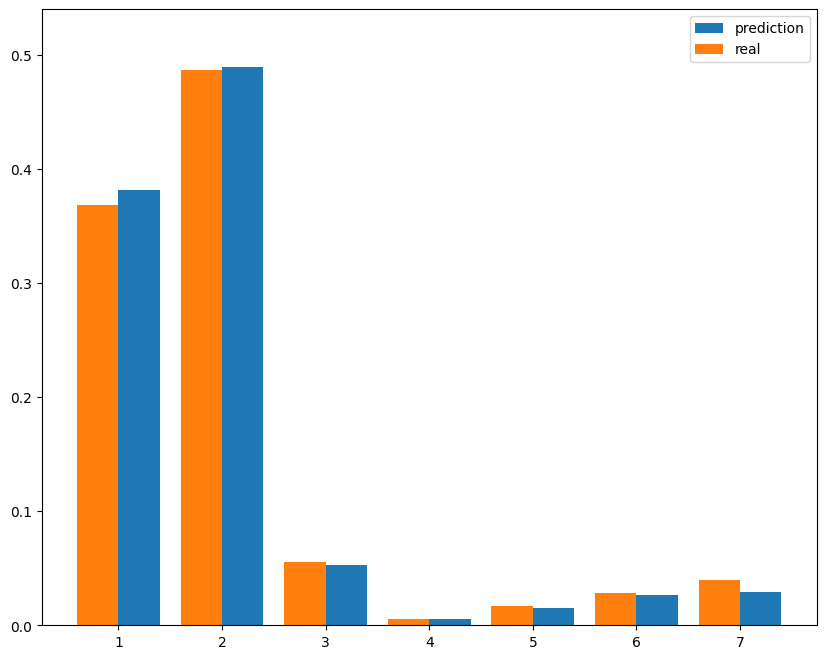

kNN accuracy: 0.7845


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression accuracy: 0.6645


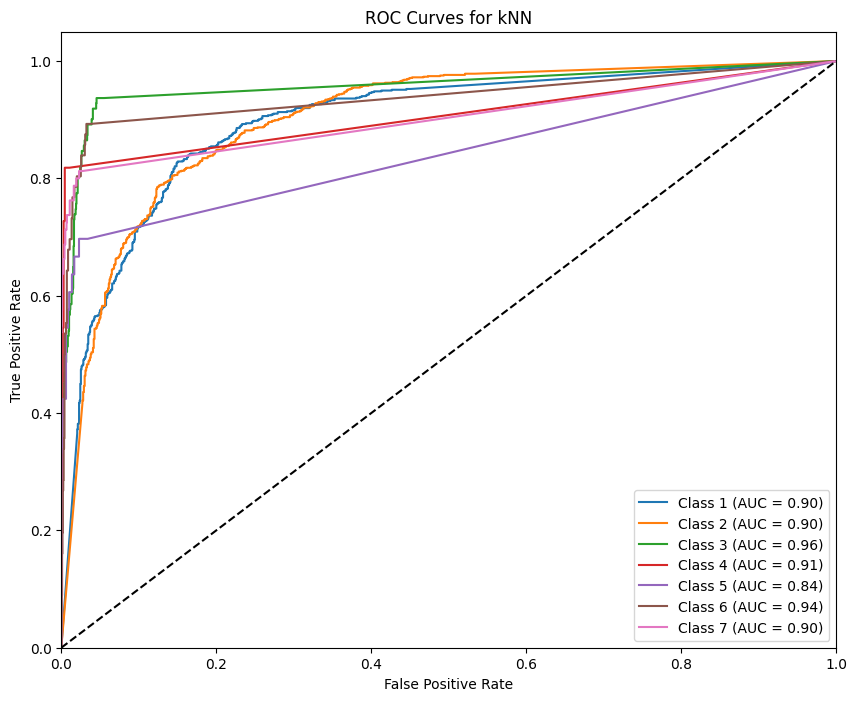

Mean AUC-ROC: 0.9063452430548241


In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression

all_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/kNN/forest_dataset.csv')

labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values

train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(
    feature_matrix, labels, test_size=0.2, random_state=42)

clf = KNeighborsClassifier()
clf.fit(train_feature_matrix, train_labels)
y_pred = clf.predict(test_feature_matrix)
print("Initial kNN accuracy:", accuracy_score(test_labels, y_pred))

params = {
    'n_neighbors': range(1, 11),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance']
}

clf_grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1)
clf_grid.fit(train_feature_matrix, train_labels)

print("Best parameters:", clf_grid.best_params_)

optimal_clf = clf_grid.best_estimator_
optimal_clf.fit(train_feature_matrix, train_labels)
pred_prob = optimal_clf.predict_proba(test_feature_matrix)

unique, freq = np.unique(test_labels, return_counts=True)
freq = list(map(lambda x: x / len(test_labels), freq))

pred_freq = pred_prob.mean(axis=0)
plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=0.4, align="edge", label='prediction')
plt.bar(range(1, 8), freq, width=-0.4, align="edge", label='real')
plt.ylim(0, 0.54)
plt.legend()
plt.show()

y_pred_optimal = optimal_clf.predict(test_feature_matrix)
print("kNN accuracy:", accuracy_score(test_labels, y_pred_optimal))

clf_lr = LogisticRegression(C=4, penalty='l1', solver='saga', max_iter=1000)
clf_lr.fit(train_feature_matrix, train_labels)
y_pred_lr = clf_lr.predict(test_feature_matrix)
print("Logistic Regression accuracy:", accuracy_score(test_labels, y_pred_lr))

test_labels_bin = label_binarize(test_labels, classes=[1, 2, 3, 4, 5, 6, 7])
pred_prob_optimal = optimal_clf.predict_proba(test_feature_matrix)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(7):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], pred_prob_optimal[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(7):
    plt.plot(fpr[i], tpr[i], label=f'Class {i+1} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for kNN')
plt.legend(loc="lower right")
plt.show()

print("Mean AUC-ROC:", np.mean(list(roc_auc.values())))